### 2_1 - Train    on    geometrique of query (  Umap )

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k_geo_semant_umap.csv')
cols = ['query' , 'Unnamed: 0' , 'emb_0','emb_1' ,'emb_2' ,'emb_3' ,'emb_4' ,'emb_5' ,'emb_6' ,'emb_7' ,'emb_8' ,'emb_9' ,'emb_10' ,'emb_11' ,'emb_12' ,'emb_13' ,'emb_14'  ] 

#only geo
x = data.drop(columns=cols)

In [2]:
x.head(3)

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
0,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665
1,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665
2,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665


#### Kmeans

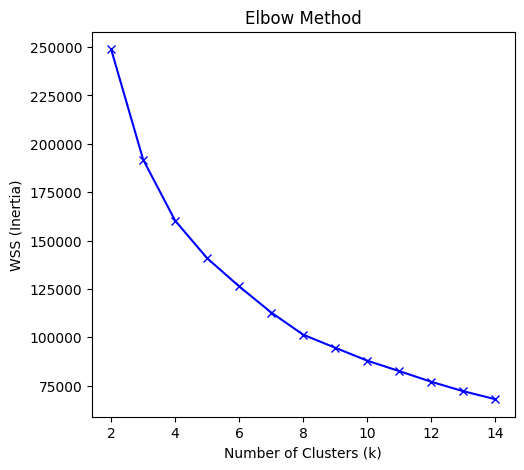

In [6]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [7]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

for k in range(50, 200, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.5270697481794511
3 0.3596127863384777
4 0.36597461768285877
5 0.3243866264886422
6 0.32595013672183804
7 0.34484959144746624
8 0.3438776655719424
9 0.3326101343165474
50 0.4472908679868771
65 0.46754602564101916
80 0.47465390876907243
95 0.4755607991790632
110 0.49878032345275813
125 0.5178074468732546
140 0.5332699356381505
155 0.5269094284001219
170 0.5432260391039848
185 0.5475595620380065


In [23]:
#Kmeans Model 

kmeans_final = KMeans(n_clusters=2, random_state=41, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
1    42016
0     7984
Name: count, dtype: int64


In [10]:
for i in range(2):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(15).values)


--- Examples of Cluster 0 ---
<StringArray>
[       'brother tn730 high yield black toner',
                                   '60 lashes',
                               'iphone used 6',
                       'compost bags 3 gallon',
      '06 suzuki 600 side fairing not painted',
                               'ffp2 not kn95',
                          'rear rack duke 390',
                 '0 size 4 pads without wings',
                              'diapers size 3',
                          '1 inch block heels',
                               'hose reel 1/4',
              ''oh no not you again' door mat',
                'otterbox iphone 7 case black',
                    '5x flip magnifying glass',
 '10 oz nuk learner sippy cup without handles']
Length: 15, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[                           'workout weights',
                        'nintendo gift cards',
                              'urban skin rx',
                          

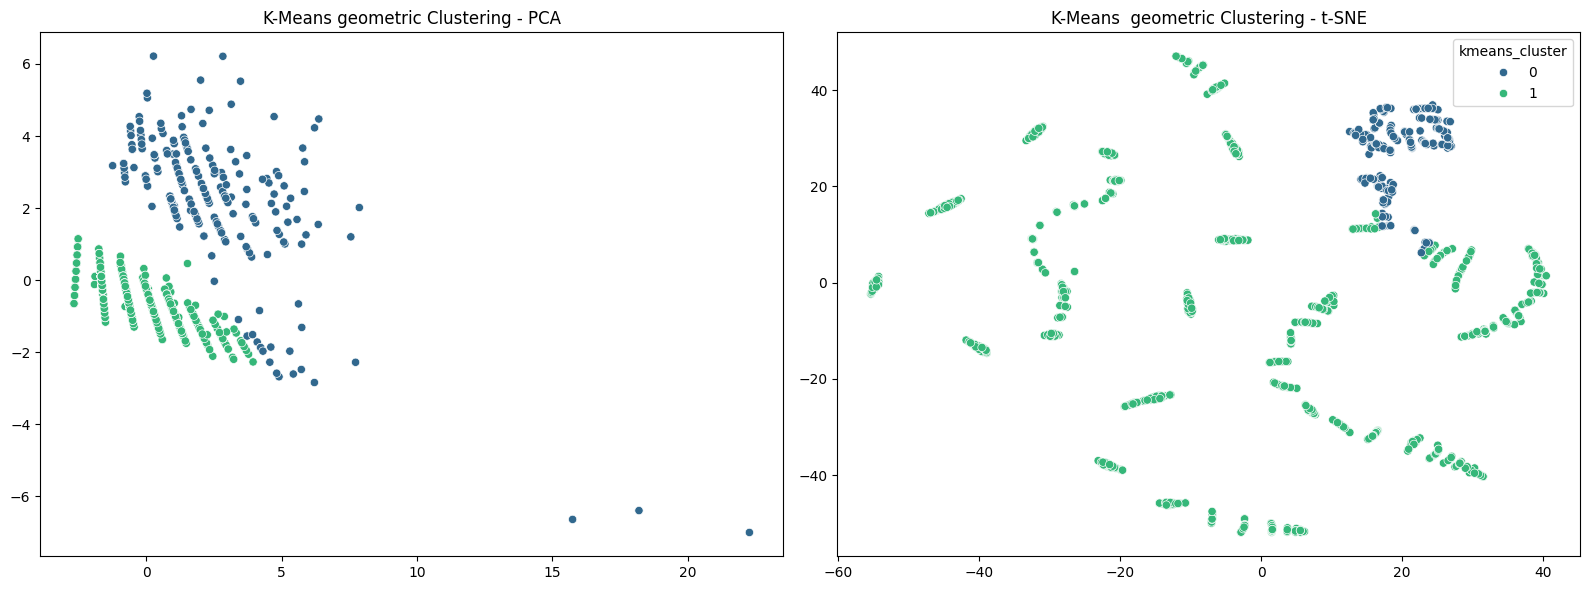

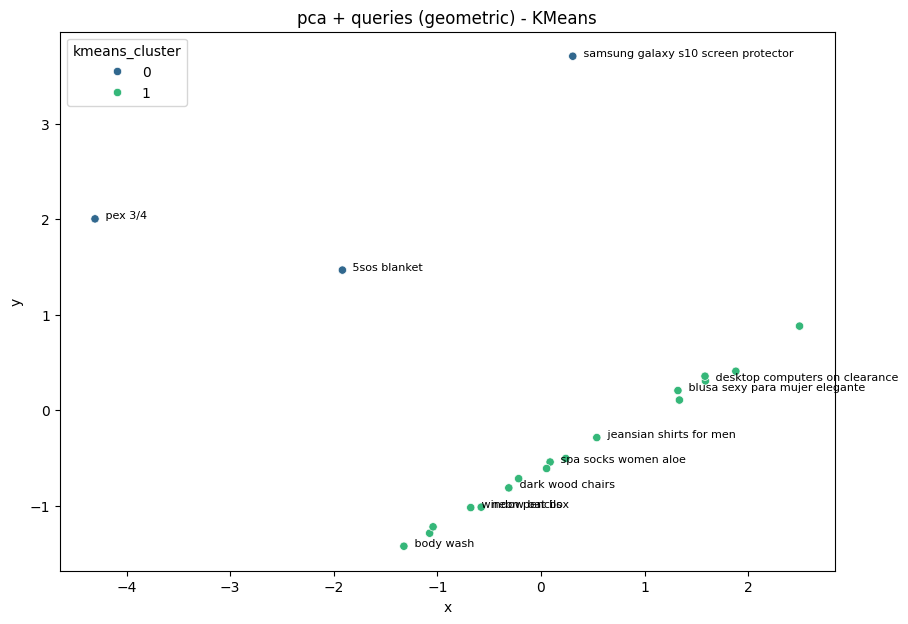

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['kmeans_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("K-Means geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("K-Means  geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=103)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='kmeans_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['kmeans_cluster'].unique():
    cluster_points = sample[sample['kmeans_cluster'] == cluster].head(8)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (geometric) - KMeans")
plt.show()

#### GMM

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Sample for speed
sample_idx = np.random.choice(len(x), size=min(5000, len(x)), replace=False)
x_sample = x.iloc[sample_idx] if hasattr(x, 'iloc') else x[sample_idx]

bic_scores = []
aic_scores = []
K_range = range(5, 101, 5)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=3
    )
    gmm.fit(x_sample)
    bic_scores.append(gmm.bic(x_sample))
    aic_scores.append(gmm.aic(x_sample))
    print(f"K={k}  BIC={gmm.bic(x_sample):.2f}  AIC={gmm.aic(x_sample):.2f}")

In [35]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

#gmm model
gmm = GaussianMixture(n_components=2, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x)


In [16]:
for i in range(2):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(20).values)


--- GMM Cluster 0 ---
<StringArray>
[                '+foot cream without alcohol',
        'brother tn730 high yield black toner',
                                   '60 lashes',
                               'iphone used 6',
                       'compost bags 3 gallon',
      '06 suzuki 600 side fairing not painted',
                 'jewellery+box+small+crystal',
                         'women's dress socks',
                               'ffp2 not kn95',
                          'rear rack duke 390',
                 '0 size 4 pads without wings',
                              'diapers size 3',
                          '1 inch block heels',
                               'hose reel 1/4',
              ''oh no not you again' door mat',
                'otterbox iphone 7 case black',
                    '5x flip magnifying glass',
 '10 oz nuk learner sippy cup without handles',
                               '9mm ammo cans',
                                      'bat181']
Len

In [17]:
# probability 
probs = gmm.predict_proba(x)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights            1             1.0
1                   nintendo gift cards            1             1.0
2                         urban skin rx            1             1.0
3                             bird seed            1             1.0
4           +foot cream without alcohol            0             1.0
5  brother tn730 high yield black toner            0             1.0
6                             60 lashes            0             1.0
7                          cpap filters            1             1.0
8         long cord lavalier microphone            1             1.0
9               tumblers bulk wholesale            1             1.0


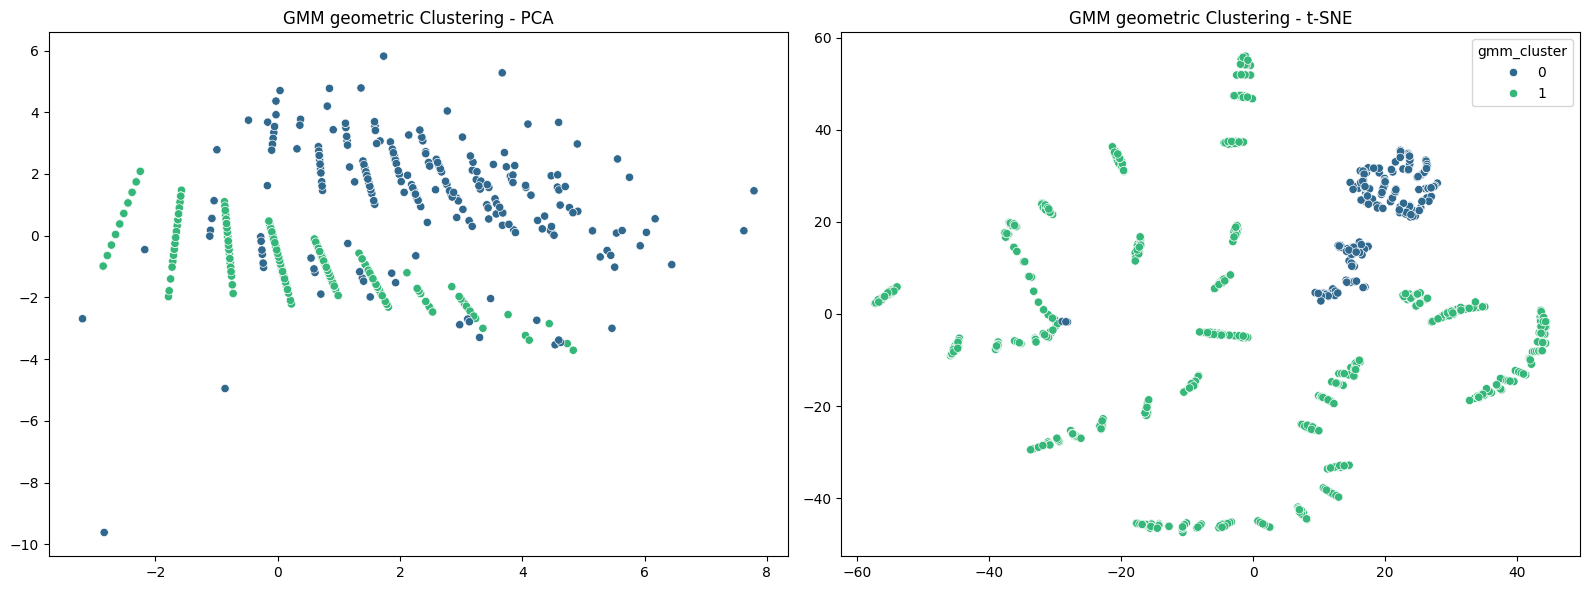

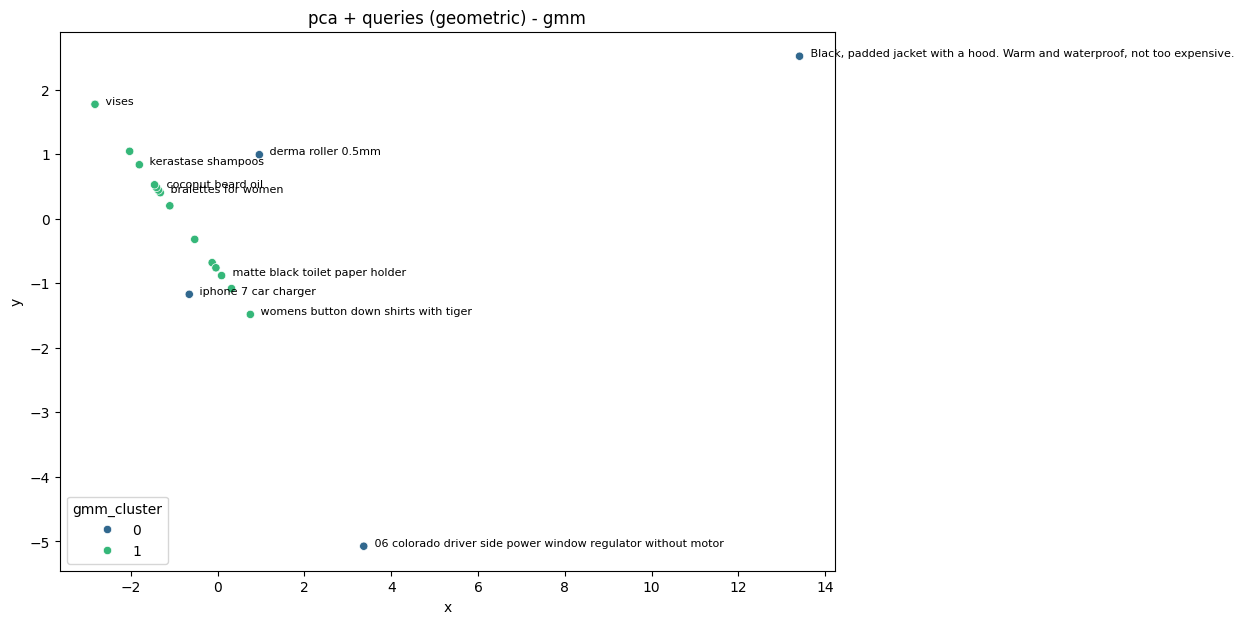

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['gmm_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=41)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("GMM geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("GMM geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=381)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='gmm_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['gmm_cluster'].unique():
    cluster_points = sample[sample['gmm_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (geometric) - gmm")
plt.show()

#### DBscan

Suggested eps: 0.1760


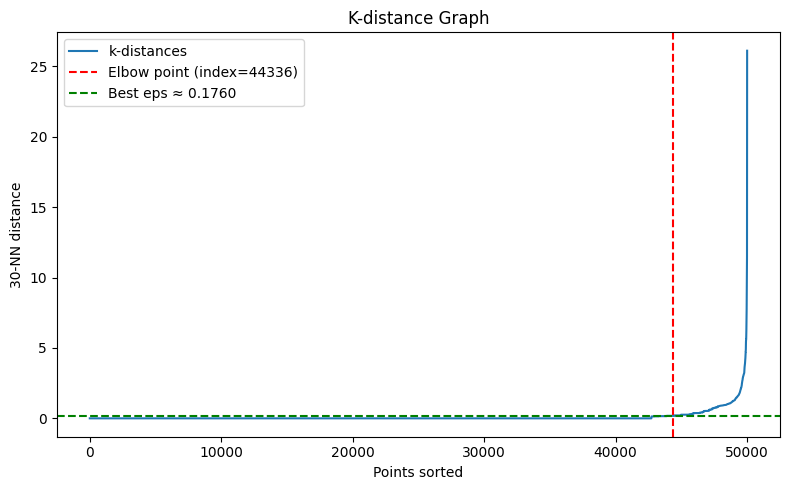

In [24]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from kneed import KneeLocator

k = 30
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

distances = np.sort(distances[:, k-1])

# Detect elbow/knee point
kneedle = KneeLocator(
    range(len(distances)), 
    distances, 
    curve="convex", 
    direction="increasing",
    interp_method="polynomial" 
)

best_eps = distances[kneedle.knee]
print(f"Suggested eps: {best_eps:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(distances, label="k-distances")
plt.axvline(x=kneedle.knee, color="red", linestyle="--", label=f"Elbow point (index={kneedle.knee})")
plt.axhline(y=best_eps, color="green", linestyle="--", label=f"Best eps ≈ {best_eps:.4f}")
plt.title("K-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel(f"{k}-NN distance")
plt.legend()
plt.tight_layout()
plt.show()
#

In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.176,min_samples=50
)

labels = dbscan.fit_predict(x)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
-1     6930
 14    4722
 9     1855
 7     1450
 1     1426
       ... 
 83      52
 85      52
 48      51
 68      50
 84      30
Name: count, Length: 92, dtype: int64

 Cluster -1
['+foot cream without alcohol', 'brother tn730 high yield black toner', '60 lashes', '06 suzuki 600 side fairing not painted', 'jewellery+box+small+crystal']

 Cluster 0
['workout weights', 'lebel cosmetics', 'christmas cards', 'satco lightbulb', 'caladora dewalt']

 Cluster 1
['nintendo gift cards', 'minnie womens shirt', 'card holder lanyard', 'japanese chin gifts', 'siamond clean brush']

 Cluster 2
['urban skin rx', 'lsu shirt men', 'shoes for men', 'par light bag', 'art tube pipe']

 Cluster 3
['bird seed', 'cdj stand', 'face mask', 'auto wrap', 'dr pawpaw']

 Cluster 4
['cpap filters', 'loctite blue', 'mugwort herb', 'address book', 'kids pajamas']

 Cluster 5
['long cord lavalier microphone', 'mexican decorations for party', 'isavera gel packs replacement', 'calligraphy set for beginners'

C:\Users\Original Computer\AppData\Local\Temp\ipykernel_13600\2435142479.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')


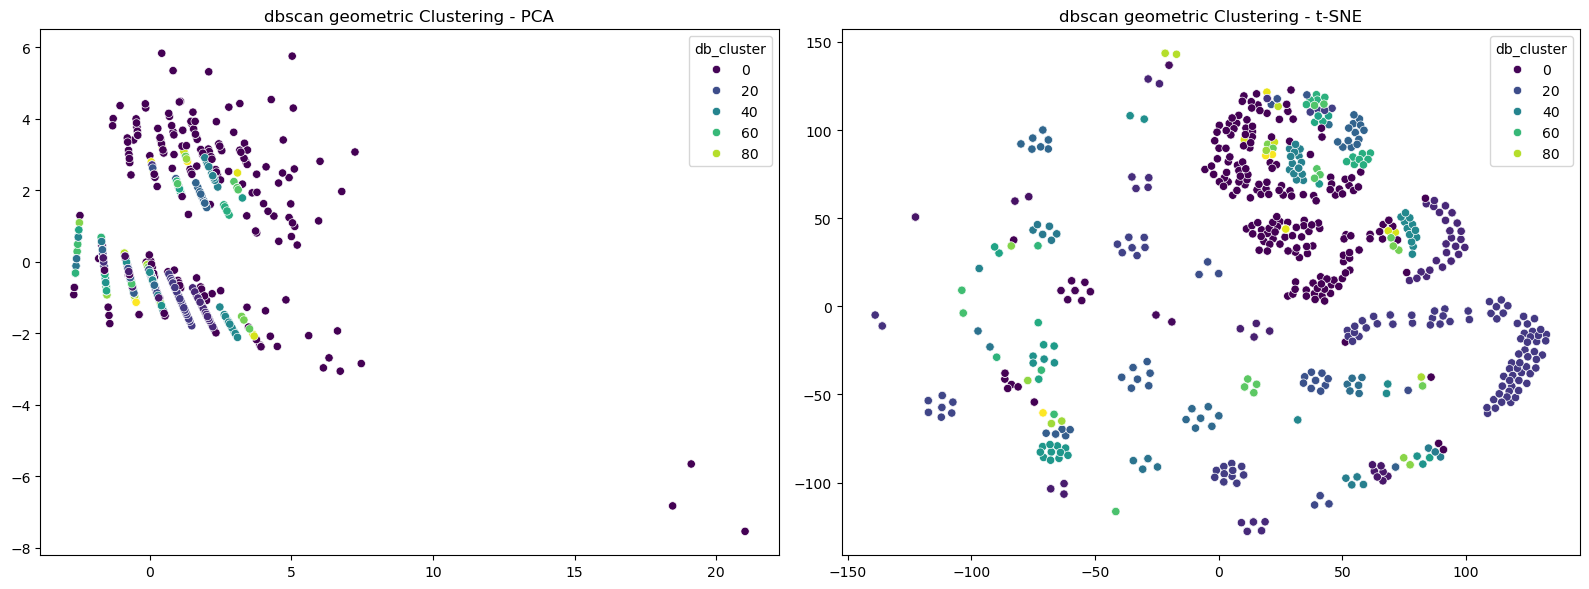

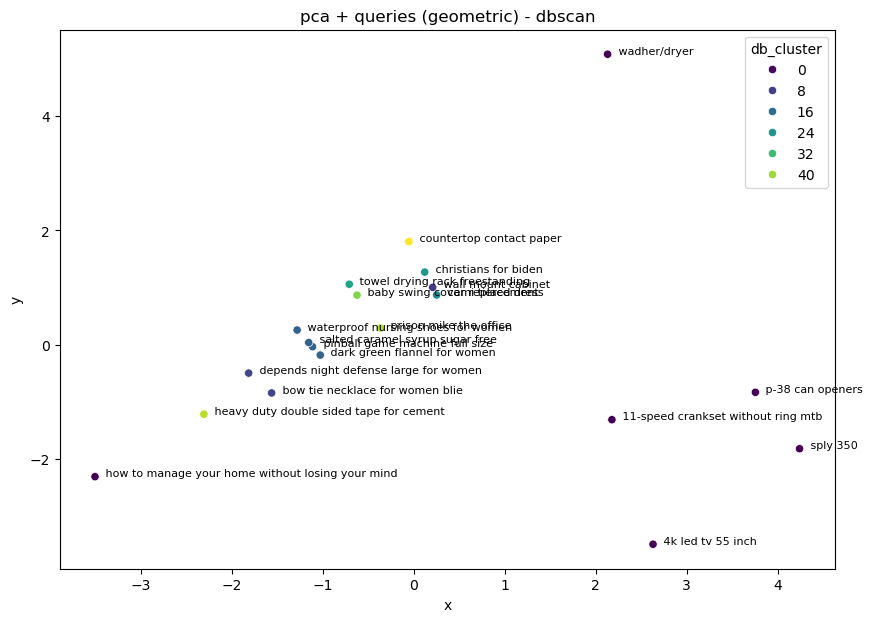

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['db_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=412)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    
)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
axes[0].set_title("dbscan geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("dbscan geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=7)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='db_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['db_cluster'].unique():
    cluster_points = sample[sample['db_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (geometric) - dbscan")
plt.show()

### hdbscan

In [30]:
import optuna
import hdbscan
import numpy as np

def objective(trial):
    # Define the ranges for the "best" parameters
    mcs = trial.suggest_int('min_cluster_size', 40, 300)
    ms = trial.suggest_int('min_samples', 1, 50)
    ep = trial.suggest_float('epsilon', 0.0, 0.3)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_epsilon=ep,
        cluster_selection_method='leaf',
        core_dist_n_jobs=-1
    )
    
    labels = clusterer.fit_predict(x) # Use your UMAP-reduced data
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels)
    
    # Penalty if there are too few clusters or too much noise
    if n_clusters < 40 or noise_pct > 0.30:
        return -1.0
    
    # We use a sample for speed to calculate the DBCV score
    try:
        idx = np.random.choice(len(x), 5000, replace=False)
        score = hdbscan.validity.validity_index(x.values[idx].astype(np.float64), labels[idx])
    except:
        score = -1
        
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30 trials is usually enough to find the peak

print("Best Parameters:", study.best_params)

[I 2026-05-11 21:00:33,407] A new study created in memory with name: no-name-1cf029fe-5def-4667-a392-dbcd3e74d214
[I 2026-05-11 21:00:46,670] Trial 0 finished with value: 0.8365273499442378 and parameters: {'min_cluster_size': 55, 'min_samples': 43, 'epsilon': 0.15730817694133625}. Best is trial 0 with value: 0.8365273499442378.
[I 2026-05-11 21:00:55,425] Trial 1 finished with value: 0.6849088850334132 and parameters: {'min_cluster_size': 288, 'min_samples': 45, 'epsilon': 0.03880046356986905}. Best is trial 0 with value: 0.8365273499442378.
[I 2026-05-11 21:01:04,149] Trial 2 finished with value: 0.7185804320904747 and parameters: {'min_cluster_size': 173, 'min_samples': 13, 'epsilon': 0.09867798911847822}. Best is trial 0 with value: 0.8365273499442378.
[I 2026-05-11 21:01:13,695] Trial 3 finished with value: 0.7600508199082857 and parameters: {'min_cluster_size': 125, 'min_samples': 17, 'epsilon': 0.13502004596678366}. Best is trial 0 with value: 0.8365273499442378.
[I 2026-05-11 2

Best Parameters: {'min_cluster_size': 43, 'min_samples': 50, 'epsilon': 0.04783593058807918}


In [31]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=43,    
    min_samples=50,     
    cluster_selection_epsilon=0.047,  
)

labels_hdb = clusterer.fit_predict(x)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
-1      3324
 25     1450
 26     1426
 17     1386
 19     1317
        ... 
 115      52
 107      52
 106      52
 100      51
 137      51
Name: count, Length: 164, dtype: int64

 HDBscan Cluster -1 ---
['06 suzuki 600 side fairing not painted', 'jewellery+box+small+crystal', 'hose reel 1/4', 'bat181', 'pma ep-2']

 HDBscan Cluster 0 ---
['kyb', 'fan', 'tkb', 'pen', 'sky']

 HDBscan Cluster 1 ---
['vita', 'kaws', 'skis', 'sofa', 'mous']

 HDBscan Cluster 2 ---
['chainsaw', 'vibrater', 'creatine', 'melodyne', 'beyblade']

 HDBscan Cluster 3 ---
['handsoaps', 'cosmetics', 'suavecito', 'querticin', 'meowscles']

 HDBscan Cluster 4 ---
['vises', 'legos', 'dnven', 'masks', 'resin']

 HDBscan Cluster 5 ---
['llllll', 'nigger', 'celery', 'shazam', 'aelfox']

 HDBscan Cluster 6 ---
['anziner', 'coleman', 'bridges', 'calzuro', 'skiyaki']

 HDBscan Cluster 7 ---
['sparklers fireworks', 'parkinsons utensils', 'falljraven backpack', 'imaginext dinosaurs', 'skateboard stickers']

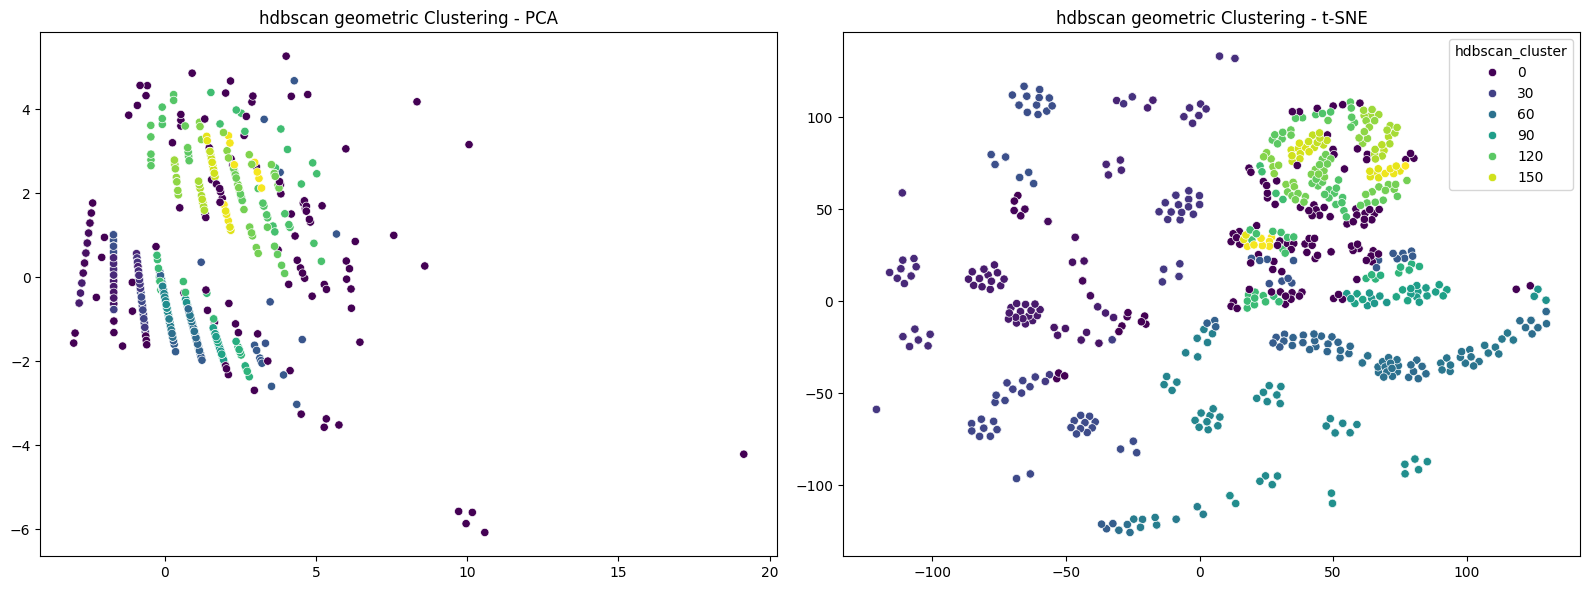

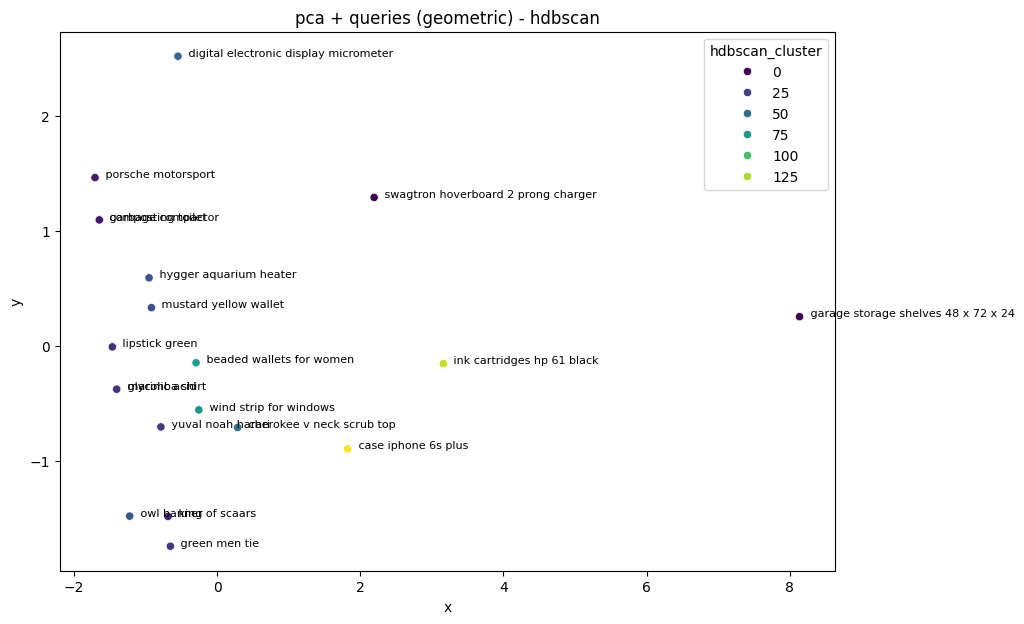

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['hdbscan_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=1)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("hdbscan geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("hdbscan geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=81)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='hdbscan_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['hdbscan_cluster'].unique():
    cluster_points = sample[sample['hdbscan_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (geometric) - hdbscan")
plt.show()

### evaluating

In [36]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [37]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=15000, replace=False)
X_sample = x.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.530370       20764.163733        1.133802           2
1      gmm    0.515438       18616.373211        1.268021           2
2   dbscan    0.847860       15745.928846        0.374205          91
3  hdbscan    0.915885       19067.766994        0.488683         163
